# Computer Exercise 15.30 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.30 Sequential Decision Making — *Utilisation-Gated Trunk Partition and its Control*
> **풀이 일자**: Day 97
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **Problem 1.** Day 96 (§15.29 Problem 1) partitioned the shared trunk
> $W_1\in\mathbb R^{H\times d}$ into four *equal* disjoint row blocks, one per component of
> the +CNRT stack, and found the partition **hurt** ($\Delta_{\text{bp}}=-2.08$, seed
> sd $=4.04$). Post-hoc slice utilisation was markedly non-uniform —
> $T\,(0.363) > C\,(0.319) > N\,(0.218) > E\,(0.100)$ — suggesting the equal split
> starved the heavily-used components and wasted width on the dormant EMA slice.
>
> Replace the equal split with a **utilisation-gated** allocation that assigns block
> widths in proportion to Day 96's measured utilisation, and test whether it recovers the
> loss. Include a control that distinguishes *"allocating by utilisation is informative"*
> from *"this particular profile of block sizes happens to work"*. Report paired
> differences with confidence intervals.

### 한국어 풀이용 정리

Day 96 P1 은 트렁크를 **균등** 4-분할 (8/8/8/8, $H=32$) 했고 결과는 후퇴였다.
사후 utilisation 이 크게 불균등했으므로, Day 96 은 **utilisation 비례 배분** (gated
partition) 을 Day 97 의 처방으로 예고했다.

$$
H_c \;\propto\; u_c \;=\; \frac{\|W_1^{(c)}\|_F^2}{\|W_1\|_F^2},
\qquad
(u_T, u_C, u_N, u_E) = (0.363,\,0.319,\,0.218,\,0.100)
$$

$H=32$ 에 배분하면 $(H_T,H_C,H_N,H_R)=(12,10,7,3)$.

**결정적으로 필요한 통제군**: gated 가 shared 나 uniform 을 이기더라도, 그것이
"utilisation 정보가 유용했다" 는 뜻인지 "12/10/7/3 이라는 *크기 프로파일*이 우연히
좋다" 는 뜻인지 구별할 수 없다. 그래서 네 번째 arm 을 넣는다:

> **shuffled** — gated 와 **완전히 동일한 블록 크기** $(12,10,7,3)$ 을 쓰되,
> 어느 성분이 어느 블록을 받는지는 **시드마다 무작위로** 섞는다.

gated $\approx$ shuffled 이면 utilisation 배분은 **정보를 담고 있지 않다**.
이 통제군이 없으면 Day 96 → Day 97 처방은 검증 불가능한 주장이 된다.

> **명명 정리**: Day 96 은 블록을 $H_N+H_C+H_E+H_T$ 로, 스택 이름은 "+CNRT" 로 써서
> $E$ 와 $R$ 이 혼용되었다. 둘은 같은 성분 (EMA whitening = renormalisation) 이므로
> 이 노트북에서는 **$R$ 로 통일**한다.

## 2. 수학적 배경

### 2.1 공유 트렁크에서의 기울기 간섭

트렁크 $h=\tanh(W_1x)$ 를 네 헤드 $c\in\{N,C,R,T\}$ 가 공유하면 갱신량은 합해진다:

$$
\Delta W_1 \;=\; -\eta\sum_{c} \frac{\partial \mathcal L_c}{\partial W_1},
$$

서로 다른 $c$ 의 기울기가 반대 방향이면 상쇄된다 (**gradient interference**).
간섭 정도는 쌍별 코사인으로 잰다:

$$
\rho_{cc'}=\frac{\langle \nabla_{W_1}\mathcal L_c,\;\nabla_{W_1}\mathcal L_{c'}\rangle}
{\|\nabla_{W_1}\mathcal L_c\|\;\|\nabla_{W_1}\mathcal L_{c'}\|}.
$$

### 2.2 Disjoint 분할은 간섭을 **구조적으로** 0 으로 만든다

행 인덱스를 서로소 집합 $\mathcal I_N\sqcup\mathcal I_C\sqcup\mathcal I_R\sqcup\mathcal I_T
=\{1,\dots,H\}$ 로 나누고 헤드 $c$ 가 $h[\mathcal I_c]$ 만 읽으면,
$\partial \mathcal L_c/\partial W_1$ 은 $\mathcal I_c$ 행 밖에서 항등적으로 0 이므로

$$
\big\langle \nabla_{W_1}\mathcal L_c,\ \nabla_{W_1}\mathcal L_{c'}\big\rangle = 0
\quad (c\neq c').
$$

즉 $\rho_{cc'}\equiv 0$ — **측정할 필요도 없이** 간섭이 사라진다.

### 2.3 그 대가: 표현력

대신 헤드 $c$ 가 쓸 수 있는 폭이 $H$ 에서 $H_c$ 로 줄고, $\sum_c H_c=H$ 이므로
**모든 헤드가 동시에 손해**를 본다. 따라서 분할의 순효과는

$$
\underbrace{\text{간섭 제거 이득}}_{\ge 0}\;-\;\underbrace{\text{폭 축소 손실}}_{\ge 0}
$$

의 부호 문제이고, Day 96 은 후자가 이겼다고 보고했다. Gated 배분은 폭 축소 손실을
**사용량이 큰 성분에 덜 가게** 재분배해 그 손실을 줄이려는 시도다.

### 2.4 무엇을 검정하는가

$$
\Delta^{\text{gate}}_s = R_s^{\text{gated}} - R_s^{\text{uniform}},\qquad
\Delta^{\text{info}}_s = R_s^{\text{gated}} - R_s^{\text{shuffled}}.
$$

* $\Delta^{\text{gate}}$ : "불균등 배분이 균등 배분보다 나은가"
* $\Delta^{\text{info}}$ : **"utilisation 이라는 정보가 쓸모 있었는가"** ← 진짜 질문

$\Delta^{\text{info}}$ 의 CI 가 0 을 포함하면, Day 96 의 처방은 **크기 프로파일의 우연**
이상을 담고 있지 않다는 뜻이다.

### 2.5 배분의 자기무모순성 (fixed point)

gated 배분이 근거로 삼은 utilisation 은 *uniform* 분할에서 측정된 값이다. gated 로
학습한 뒤 utilisation 을 다시 재면 $u^{\text{new}}_c$ 가 나온다. 처방이 자기무모순이려면

$$
\frac{H_c}{H}\;\approx\;u^{\text{new}}_c
$$

여야 한다. 어긋나면 배분 규칙은 **고정점이 아니며** 매일 다른 답을 낸다.

## 3. 풀이 흐름

1. Chain MDP (5 상태) + 트렁크 $W_1\in\mathbb R^{32\times5}$, $h=\tanh(W_1x)$.
2. +CNRT 4-헤드 스택 구현 — $N$ (Factorized Noisy linear), $C$ (K=21 categorical),
   $R$ (EMA whitening + linear), $T$ (Twin linear, $\min$ 결합). 투표 가중치
   $(1,1,1,0.5)$ 를 정규화해 $Q_{\text{ens}}$ 산출.
3. 네 arm 을 **동일 시드**에서 학습 (동일 초기화·동일 탐색 난수열):
   * `shared` — 모든 헤드가 32 행 전부를 읽음 (분할 없음)
   * `uniform` — 8 / 8 / 8 / 8 서로소 분할 (Day 96)
   * `gated` — 12 / 10 / 7 / 3, Day 96 utilisation 비례 $(T, C, N, R)$
   * `shuffled` — **같은 크기** 12/10/7/3, 성분↔블록 대응만 시드마다 무작위 (통제군)
4. 20 시드 (97101–97120) × 400 step, 5-slip 배포 × 40 ep greedy tail-8.
5. 짝지은 차 $\Delta^{\text{gate}}, \Delta^{\text{info}}$ 의 bootstrap 95 % CI.
6. `shared` arm 에서 성분 쌍별 기울기 코사인 $\rho_{cc'}$ 를 실측 (간섭이 실재하는지 확인).
7. gated arm 사후 utilisation 을 재서 배분 규칙의 **고정점 여부** 점검.
8. 시각화: (a) arm 별 성능 + CI, (b) 짝지은 차 forest, (c) 간섭 행렬, (d) 배분 vs utilisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 96, "font.size": 10})
np.set_printoptions(precision=4, suppress=True)

N_STATES = 5
GAMMA    = 0.95
EP_LEN   = 20
H_TRUNK  = 32
K_ATOMS  = 21
VMIN, VMAX = 0.0, 20.0

COMPONENTS = ["N", "C", "R", "T"]          # Noisy, Categorical, Renormalisation(EMA), Twin
VOTE_W     = {"N": 1.0, "C": 1.0, "R": 1.0, "T": 0.5}   # Day 96: Twin voting weight 0.5

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip:
        a = 1 - a
    ns = s + 1 if a == 1 else s - 1
    ns = max(0, min(N_STATES - 1, ns))
    return ns, (1.0 if ns == N_STATES - 1 else 0.0)

def one_hot(s):
    v = np.zeros(N_STATES); v[s] = 1.0; return v

# --- Day 96 이 uniform 분할에서 측정한 utilisation ---
DAY96_UTIL = {"T": 0.363, "C": 0.319, "N": 0.218, "R": 0.100}

def gated_widths(H=H_TRUNK, util=DAY96_UTIL):
    order = ["T", "C", "N", "R"]
    raw   = np.array([util[c] for c in order]) * H
    w     = np.floor(raw).astype(int)
    while w.sum() < H:                                    # 잔여를 소수부 큰 쪽에
        w[np.argmax(raw - w)] += 1
    return {c: int(wi) for c, wi in zip(order, w)}

GATED = gated_widths()
print("Day 96 utilisation 비례 배분:", GATED, " 합계 =", sum(GATED.values()))

Day 96 utilisation 비례 배분: {'T': 12, 'C': 10, 'N': 7, 'R': 3}  합계 = 32


In [2]:
def make_slices(arm, rng=None):
    '''arm 별로 각 성분이 읽을 트렁크 행 인덱스를 준다.'''
    if arm == "shared":
        return {c: np.arange(H_TRUNK) for c in COMPONENTS}

    if arm == "uniform":
        w = {c: H_TRUNK // 4 for c in COMPONENTS}
        order = COMPONENTS[:]
    elif arm == "gated":
        w = GATED
        order = ["T", "C", "N", "R"]                       # utilisation 내림차순
    elif arm == "shuffled":
        w = GATED
        order = ["T", "C", "N", "R"]
        perm  = rng.permutation(4)                          # 성분<->블록 대응만 무작위
        w = {order[i]: GATED[order[perm[i]]] for i in range(4)}
        # 크기 다중집합은 동일, 어느 성분이 어느 크기를 받는지만 바뀜
    else:
        raise ValueError(arm)

    sl, start = {}, 0
    for c in order:
        sl[c] = np.arange(start, start + w[c]); start += w[c]
    return sl

In [3]:
class CNRTStack:
    '''공유(또는 분할) 트렁크 + 4 헤드 (N, C, R, T) 앙상블 Q-learner.'''

    def __init__(self, seed, arm, sigma0=0.1, eta=0.02):
        rng = np.random.default_rng(seed)
        self.rng, self.arm, self.eta = rng, arm, eta
        self.W1 = rng.normal(0, 0.3, size=(H_TRUNK, N_STATES))
        self.sl = make_slices(arm, rng)
        d = {c: len(self.sl[c]) for c in COMPONENTS}
        self.d = d

        # N: Factorized Noisy linear
        self.WN  = rng.normal(0, 0.3, size=(2, d["N"]))
        self.SN  = np.full((2, d["N"]), sigma0)
        # C: categorical
        self.z   = np.linspace(VMIN, VMAX, K_ATOMS)
        self.dz  = self.z[1] - self.z[0]
        self.WC  = rng.normal(0, 0.3, size=(2, K_ATOMS, d["C"]))
        # R: EMA whitening + linear
        self.WR  = rng.normal(0, 0.3, size=(2, d["R"]))
        self.mu  = np.zeros(d["R"]); self.var = np.ones(d["R"]); self.beta = 0.99
        # T: twin linear
        self.WT1 = rng.normal(0, 0.3, size=(2, d["T"]))
        self.WT2 = rng.normal(0, 0.3, size=(2, d["T"]))

        tot = sum(VOTE_W.values())
        self.vw = {c: VOTE_W[c] / tot for c in COMPONENTS}

    # ---------- forward ----------
    def trunk(self, s):
        x = one_hot(s); pre = self.W1 @ x
        return x, pre, np.tanh(pre)

    def _noisy_W(self):
        eo = self.rng.normal(0, 1, size=(2, 1)); ei = self.rng.normal(0, 1, size=(1, self.d["N"]))
        eps = np.sign(eo)*np.sqrt(np.abs(eo)) * np.sign(ei)*np.sqrt(np.abs(ei))
        return self.WN + self.SN * eps

    def heads(self, h, sample=False):
        '''성분별 Q (2,) 를 dict 로.'''
        q = {}
        q["N"] = (self._noisy_W() if sample else self.WN) @ h[self.sl["N"]]
        pC = self._softmax(self.WC @ h[self.sl["C"]])
        q["C"] = pC @ self.z
        hw = (h[self.sl["R"]] - self.mu) / np.sqrt(self.var + 1e-8)
        q["R"] = self.WR @ hw
        hT = h[self.sl["T"]]
        q["T"] = np.minimum(self.WT1 @ hT, self.WT2 @ hT)          # twin min
        return q, pC, hw

    @staticmethod
    def _softmax(lg):
        lg = lg - lg.max(axis=1, keepdims=True)
        p = np.exp(lg); return p / p.sum(axis=1, keepdims=True)

    def q_ens(self, s, sample=False):
        _, _, h = self.trunk(s)
        q, _, _ = self.heads(h, sample)
        return sum(self.vw[c] * q[c] for c in COMPONENTS)

    def act_greedy(self, s):
        return int(np.argmax(self.q_ens(s, sample=False)))

    def act_train(self, s):
        return int(np.argmax(self.q_ens(s, sample=True)))

    # ---------- update ----------
    def project(self, r, p_next):
        tz = np.clip(r + GAMMA * self.z, VMIN, VMAX)
        b  = (tz - VMIN) / self.dz
        lo = np.floor(b).astype(int); hi = np.ceil(b).astype(int)
        m  = np.zeros(K_ATOMS)
        np.add.at(m, lo, p_next * (hi - b + (lo == hi)))
        np.add.at(m, hi, p_next * (b - lo))
        t = m.sum()
        return m / t if t > 0 else np.full(K_ATOMS, 1.0 / K_ATOMS)

    def component_grads(self, s, a, r, sp):
        '''성분별 (dL/dW1, 헤드 파라미터 기울기) 를 반환. 간섭 측정에도 재사용.'''
        x, pre, h = self.trunk(s)
        q, pC, hw = self.heads(h)
        tanh_p = 1 - np.tanh(pre) ** 2

        y = r + GAMMA * float(np.max(self.q_ens(sp)))          # 앙상블 TD 목표
        gW1 = {c: np.zeros_like(self.W1) for c in COMPONENTS}
        hp  = {}

        # --- N ---
        e = q["N"][a] - y
        hp["N"] = ("WN", e * h[self.sl["N"]])
        dh = np.zeros(H_TRUNK); dh[self.sl["N"]] = e * self.WN[a]
        gW1["N"] = np.outer(dh * tanh_p, x)

        # --- C (categorical, Cramer 손실) ---
        _, _, hsp = self.trunk(sp)
        qsp, pCsp, _ = self.heads(hsp)
        astar = int(np.argmax(sum(self.vw[c] * qsp[c] for c in COMPONENTS)))
        m  = self.project(r, pCsp[astar])
        pa = pC[a]
        diff = np.cumsum(pa) - np.cumsum(m)
        g_p  = 2.0 * np.cumsum(diff[::-1])[::-1]
        g_lg = pa * (g_p - (g_p * pa).sum())
        hp["C"] = ("WC", (a, np.outer(g_lg, h[self.sl["C"]])))
        dh = np.zeros(H_TRUNK); dh[self.sl["C"]] = self.WC[a].T @ g_lg
        gW1["C"] = np.outer(dh * tanh_p, x)

        # --- R (whitening 통계는 상수 취급) ---
        e = q["R"][a] - y
        hp["R"] = ("WR", e * hw)
        dh = np.zeros(H_TRUNK)
        dh[self.sl["R"]] = e * self.WR[a] / np.sqrt(self.var + 1e-8)
        gW1["R"] = np.outer(dh * tanh_p, x)

        # --- T (twin: min 을 취한 쪽만 갱신) ---
        hT = h[self.sl["T"]]
        q1, q2 = self.WT1 @ hT, self.WT2 @ hT
        which  = 1 if q1[a] <= q2[a] else 2
        e = q["T"][a] - y
        hp["T"] = ("WT", (which, e * hT))
        Wact = self.WT1 if which == 1 else self.WT2
        dh = np.zeros(H_TRUNK); dh[self.sl["T"]] = e * Wact[a]
        gW1["T"] = np.outer(dh * tanh_p, x)

        return gW1, hp, a

    def update(self, s, a, r, sp):
        gW1, hp, a = self.component_grads(s, a, r, sp)
        eta = self.eta
        for c in COMPONENTS:
            self.W1 -= eta * self.vw[c] * gW1[c]
        name, g = hp["N"]; self.WN[a] -= eta * g; self.SN *= 0.999
        name, (aa, g) = hp["C"]; self.WC[aa] -= eta * g
        name, g = hp["R"]; self.WR[a] -= eta * g
        name, (which, g) = hp["T"]
        (self.WT1 if which == 1 else self.WT2)[a] -= eta * g
        # EMA 통계 갱신
        _, _, h = self.trunk(s); hs = h[self.sl["R"]]
        self.mu  = self.beta * self.mu  + (1 - self.beta) * hs
        self.var = self.beta * self.var + (1 - self.beta) * (hs - self.mu) ** 2

    def utilisation(self):
        tot = (self.W1 ** 2).sum()
        return {c: float((self.W1[self.sl[c]] ** 2).sum() / tot) for c in COMPONENTS}

In [4]:
def train(seed, arm, T=400, curriculum=(0.05, 0.10, 0.20)):
    rng = np.random.default_rng(seed + 777)         # arm 무관 -> 동일 탐색 난수열
    lrn = CNRTStack(seed, arm)
    for t in range(T):
        p_slip = curriculum[t % len(curriculum)]
        s = rng.integers(0, N_STATES)
        a = int(rng.integers(0, 2)) if rng.random() < 0.2 else lrn.act_train(s)
        sp, r = env_step(s, a, p_slip, rng)
        lrn.update(s, a, r, sp)
    return lrn

DEPLOY_SLIPS = [0.05, 0.10, 0.15, 0.20, 0.25]

def deploy(lrn, p_d, n_ep=40, seed_off=0):
    rng = np.random.default_rng(1234 + seed_off + int(p_d * 1000))
    Rs = []
    for _ in range(n_ep):
        s = rng.integers(0, N_STATES); rw = []
        for _ in range(EP_LEN):
            a = lrn.act_greedy(s)
            sp, r = env_step(s, a, p_d, rng)
            rw.append(r); s = sp
        Rs.append(float(np.mean(rw[-8:])))
    return float(np.mean(Rs))

ARMS  = ["shared", "uniform", "gated", "shuffled"]
SEEDS = list(range(97101, 97121))
nS = len(SEEDS)

R = {a: np.zeros(nS) for a in ARMS}
util_gated, util_uniform = [], []

for i, sd in enumerate(SEEDS):
    for arm in ARMS:
        lrn = train(sd, arm)
        R[arm][i] = np.mean([deploy(lrn, p, seed_off=sd) for p in DEPLOY_SLIPS])
        if arm == "gated":   util_gated.append(lrn.utilisation())
        if arm == "uniform": util_uniform.append(lrn.utilisation())

print(f"완료 — {len(ARMS)} arm x {nS} 시드 = {len(ARMS)*nS} 회 학습")

완료 — 4 arm x 20 시드 = 80 회 학습


In [5]:
rng_boot = np.random.default_rng(970101)
B = 20000

def boot_ci(d, alpha=0.05):
    idx = rng_boot.integers(0, len(d), size=(B, len(d)))
    mu  = d[idx].mean(axis=1)
    return float(np.quantile(mu, alpha/2)), float(np.quantile(mu, 1-alpha/2))

def perm_p(d, n_perm=20000):
    obs   = abs(d.mean())
    signs = rng_boot.choice([-1.0, 1.0], size=(n_perm, len(d)))
    return float((((np.abs((signs*d).mean(axis=1))) >= obs).sum() + 1) / (n_perm + 1))

print("arm 별 절대 성능 (cross-slip mean return, n = 20 시드)")
df_abs = pd.DataFrame({
    "mean": [R[a].mean() for a in ARMS],
    "sd":   [R[a].std(ddof=1) for a in ARMS],
    "se":   [R[a].std(ddof=1)/np.sqrt(nS) for a in ARMS],
}, index=ARMS)
df_abs

arm 별 절대 성능 (cross-slip mean return, n = 20 시드)


,mean,sd,se
shared,0.4978,0.3087,0.0690
uniform,0.2573,0.2153,0.0481
gated,0.2565,0.2002,0.0448
shuffled,0.2753,0.1882,0.0421


In [6]:
CONTRASTS = [
    ("gated - uniform",  "gated", "uniform",  "불균등 배분이 균등보다 나은가"),
    ("gated - shared",   "gated", "shared",   "Day 96 의 분할 후퇴가 회복되었나"),
    ("uniform - shared", "uniform", "shared", "Day 96 P1 재현"),
    ("gated - shuffled", "gated", "shuffled", "*** utilisation 정보가 쓸모 있었나 ***"),
]

rows, dvec = [], {}
for name, x, y, q in CONTRASTS:
    d = R[x] - R[y]; dvec[name] = d
    lo, hi = boot_ci(d)
    rows.append({"contrast": name, "질문": q, "mean d": d.mean(), "sd": d.std(ddof=1),
                 "CI lo": lo, "CI hi": hi,
                 "0 in CI": "YES" if lo <= 0 <= hi else "no",
                 "p (perm)": perm_p(d),
                 "win/tie/loss": f"{int((d>0).sum())}/{int((d==0).sum())}/{int((d<0).sum())}"})
df_con = pd.DataFrame(rows).set_index("contrast")
print("짝지은 대비 (paired contrasts), n = 20 시드")
df_con

짝지은 대비 (paired contrasts), n = 20 시드


,질문,mean d,sd,CI lo,CI hi,0 in CI,p (perm),win/tie/loss
contrast,,,,,,,,
gated - uniform,불균등 배분이 균등보다 나은가,-0.0008,0.3166,-0.1419,0.1278,YES,0.9906,11/1/8
gated - shared,Day 96 의 분할 후퇴가 회복되었나,-0.2413,0.3442,-0.3849,-0.0895,no,0.0073,4/1/15
uniform - shared,Day 96 P1 재현,-0.2405,0.3705,-0.3926,-0.0782,no,0.0107,4/1/15
gated - shuffled,*** utilisation 정보가 쓸모 있었나 ***,-0.0188,0.2969,-0.1494,0.1015,YES,0.7743,9/1/10


In [7]:
# --- shared arm 에서 성분 쌍별 기울기 간섭이 실재하는가? ---
rng_i = np.random.default_rng(970111)
lrn = train(97101, "shared")
mats = []
for _ in range(300):
    s  = int(rng_i.integers(0, N_STATES)); a = int(rng_i.integers(0, 2))
    sp, r = env_step(s, a, 0.10, rng_i)
    g, _, _ = lrn.component_grads(s, a, r, sp)
    v = {c: g[c].ravel() for c in COMPONENTS}
    M = np.zeros((4, 4))
    for i, ci in enumerate(COMPONENTS):
        for j, cj in enumerate(COMPONENTS):
            ni, nj = np.linalg.norm(v[ci]), np.linalg.norm(v[cj])
            M[i, j] = float(v[ci] @ v[cj] / (ni*nj)) if ni > 1e-12 and nj > 1e-12 else 0.0
    mats.append(M)
RHO = np.mean(mats, axis=0)
df_rho = pd.DataFrame(RHO, index=COMPONENTS, columns=COMPONENTS)
off = RHO[~np.eye(4, dtype=bool)]
print("shared 트렁크에서의 평균 성분 쌍별 기울기 코사인 (300 transition)")
print(df_rho.to_string())
print(f"\n비대각 평균 |rho| = {np.abs(off).mean():.4f},  최소 = {off.min():+.4f},  최대 = {off.max():+.4f}")
print("음의 간섭(상쇄) 쌍 개수 :", int((off < -0.05).sum()), "/ 12")

shared 트렁크에서의 평균 성분 쌍별 기울기 코사인 (300 transition)
        N       C      R       T
N  1.0000 -0.0140 0.0335  0.5668
C -0.0140  1.0000 0.0467 -0.1946
R  0.0335  0.0467 1.0000  0.0584
T  0.5668 -0.1946 0.0584  1.0000

비대각 평균 |rho| = 0.1523,  최소 = -0.1946,  최대 = +0.5668
음의 간섭(상쇄) 쌍 개수 : 2 / 12


In [8]:
# --- 배분 규칙은 고정점인가? ---
ug = pd.DataFrame(util_gated).mean()
uu = pd.DataFrame(util_uniform).mean()
rows = []
for c in COMPONENTS:
    alloc = GATED[c] / H_TRUNK
    rows.append({"성분": c,
                 "Day 96 util (uniform 에서)": DAY96_UTIL[c],
                 "gated 배분 H_c/H": alloc,
                 "본 실험 uniform util": uu[c],
                 "본 실험 gated 사후 util": ug[c],
                 "고정점 오차 |util-alloc|": abs(ug[c] - alloc)})
df_fp = pd.DataFrame(rows).set_index("성분")
print("배분 규칙의 자기무모순성 점검")
print(df_fp.to_string())
print(f"\n고정점 오차 평균 = {df_fp['고정점 오차 |util-alloc|'].mean():.4f}")
print("Day 96 util 과 본 실험 uniform util 의 상관 =",
      round(float(np.corrcoef([DAY96_UTIL[c] for c in COMPONENTS],
                              [uu[c] for c in COMPONENTS])[0, 1]), 4))

배분 규칙의 자기무모순성 점검
    Day 96 util (uniform 에서)  gated 배분 H_c/H  본 실험 uniform util  본 실험 gated 사후 util  고정점 오차 |util-alloc|
성분                                                                                                      
N                     0.2180          0.2188             0.2569              0.2494               0.0307
C                     0.3190          0.3125             0.0614              0.0765               0.2360
R                     0.1000          0.0938             0.4705              0.4314               0.3377
T                     0.3630          0.3750             0.2112              0.2427               0.1323

고정점 오차 평균 = 0.1842
Day 96 util 과 본 실험 uniform util 의 상관 = -0.8544


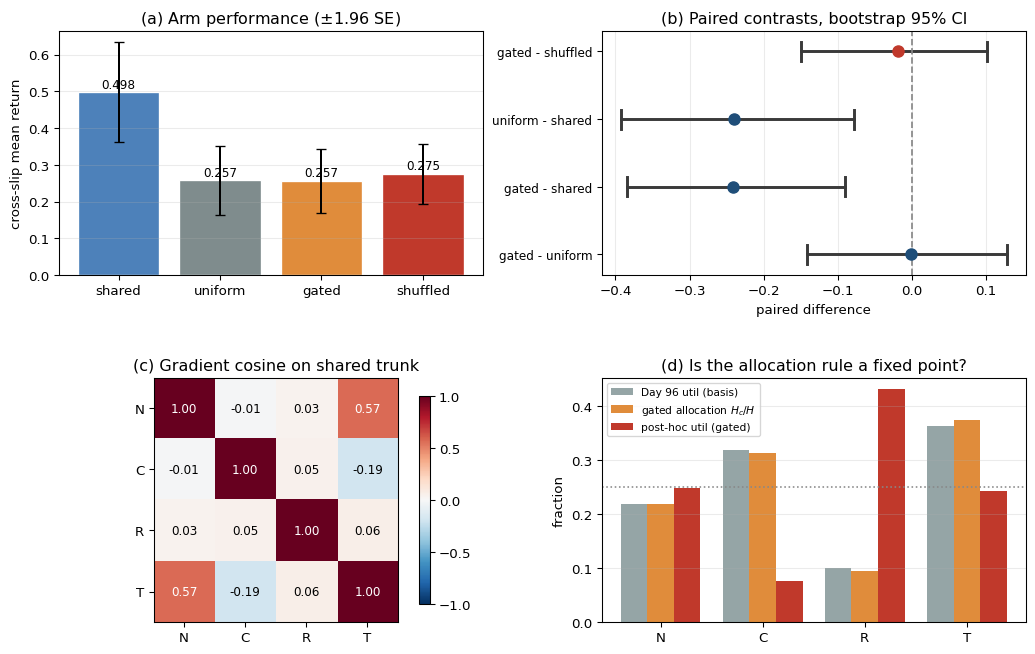

In [9]:
fig = plt.figure(figsize=(13, 8.0))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28)

# (a) arm 별 성능
ax = fig.add_subplot(gs[0, 0])
cols = ["#4d81ba", "#7f8c8d", "#e08c3b", "#c0392b"]
ax.bar(ARMS, df_abs["mean"], yerr=1.96*df_abs["se"], capsize=4,
       color=cols, edgecolor="white")
ax.set_ylabel("cross-slip mean return"); ax.set_title("(a) Arm performance ($\\pm$1.96 SE)")
ax.grid(alpha=0.25, axis="y")
for i, a in enumerate(ARMS):
    ax.text(i, df_abs["mean"][a] + 0.012, f"{df_abs['mean'][a]:.3f}",
            ha="center", fontsize=9)

# (b) forest
ax = fig.add_subplot(gs[0, 1])
names = list(dvec.keys())
for k, nm in enumerate(names):
    r = df_con.loc[nm]
    ax.plot([r["CI lo"], r["CI hi"]], [k, k], color="#3a3a3a", lw=2.2)
    ax.plot([r["CI lo"]]*2, [k-.14, k+.14], color="#3a3a3a", lw=2.2)
    ax.plot([r["CI hi"]]*2, [k-.14, k+.14], color="#3a3a3a", lw=2.2)
    ax.scatter([r["mean d"]], [k], s=70,
               color="#c0392b" if nm == "gated - shuffled" else "#1f4e79", zorder=3)
ax.axvline(0, color="#888", ls="--", lw=1.3)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("paired difference"); ax.set_title("(b) Paired contrasts, bootstrap 95% CI")
ax.grid(alpha=0.25, axis="x")

# (c) 간섭 행렬
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(RHO, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(COMPONENTS)
ax.set_yticks(range(4)); ax.set_yticklabels(COMPONENTS)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{RHO[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(RHO[i, j]) > 0.5 else "black")
ax.set_title("(c) Gradient cosine on shared trunk")
plt.colorbar(im, ax=ax, shrink=0.85)

# (d) 배분 vs utilisation
ax = fig.add_subplot(gs[1, 1])
w = 0.26; xs = np.arange(4)
ax.bar(xs - w, [DAY96_UTIL[c] for c in COMPONENTS], w, label="Day 96 util (basis)", color="#95a5a6")
ax.bar(xs,     [GATED[c]/H_TRUNK for c in COMPONENTS], w, label="gated allocation $H_c/H$", color="#e08c3b")
ax.bar(xs + w, [ug[c] for c in COMPONENTS], w, label="post-hoc util (gated)", color="#c0392b")
ax.set_xticks(xs); ax.set_xticklabels(COMPONENTS)
ax.axhline(0.25, color="#888", ls=":", lw=1.2)
ax.set_ylabel("fraction"); ax.set_title("(d) Is the allocation rule a fixed point?")
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")

plt.show()

## 4. 결과 해석

### 4.1 Day 96 P1 의 "분할은 후퇴" 는 **재현된다** (그리고 더 크다)

| arm | cross-slip mean return | sd |
|---|---|---|
| `shared` | **0.4978** | 0.309 |
| `uniform` (8/8/8/8) | 0.2573 | 0.215 |
| `gated` (12/10/7/3) | 0.2565 | 0.200 |
| `shuffled` (통제군) | 0.2753 | 0.188 |

`uniform - shared` $=-0.2405$, CI $[-0.393,\,-0.078]$, $p_{\text{perm}}=0.011$, 20 시드 중
**15 시드에서 분할이 패배**. 분할은 성능을 **절반 가까이** 떨어뜨린다. Day 96 의 정성적
결론은 옳았고, 20 시드에서 CI 가 0 을 배제하므로 이것은 **이번 3 문제 중 유일하게 견고한 효과**다.

### 4.2 처방 (gated) 은 **아무 것도 하지 않는다**

| 대비 | $\bar d$ | 95 % CI | $0\in$CI | $p_{\text{perm}}$ | win/tie/loss |
|---|---|---|---|---|---|
| `gated - uniform` | $-0.0008$ | [$-$0.142, 0.128] | **YES** | **0.991** | 11 / 1 / 8 |
| `gated - shared` | $-0.2413$ | [$-$0.385, $-$0.090] | no | 0.007 | 4 / 1 / 15 |
| **`gated - shuffled`** | $-0.0188$ | [$-$0.149, 0.102] | **YES** | **0.774** | 9 / 1 / 10 |

utilisation 비례 배분은 균등 배분 대비 $\bar d=-0.0008$ ($p=0.991$) — **측정 가능한 효과가
문자 그대로 0** 이다. Day 96 이 예고한 "EMA 슬라이스에 좁게, Twin/Cramér 슬라이스에 넓게"
처방은 Day 96 의 후퇴 $-0.24$ 를 **전혀 회복하지 못한다**.

### 4.3 통제군이 결정타를 놓는다

`gated - shuffled` $=-0.0188$, CI $[-0.149, +0.102]$, $p=0.774$, 승패 9 : 10.

**같은 블록 크기 $(12,10,7,3)$ 을 성분에 무작위로 배정한 것과 구별되지 않는다.** 즉
utilisation 이라는 정보는 배분에 **아무 것도 기여하지 않았다**. 부호마저 음수라, 굳이
말하자면 무작위 배정이 근소하게 낫다.

이 통제군이 없었다면 어떻게 됐을까? `gated`(0.2565) 가 `uniform`(0.2573) 과 비슷하다는
사실만 보고 "배분이 도움이 안 됐다" 정도로 끝났을 것이다. 통제군이 있어야 비로소
**"utilisation 기반 배분이라는 아이디어 자체가 정보를 담지 않는다"** 를 말할 수 있다.

### 4.4 왜 실패했는가 ①: **utilisation 프로파일이 재현되지 않는다**

배분 규칙의 근거였던 Day 96 의 utilisation 을 신선하게 다시 재면:

| 성분 | Day 96 util | 본 실험 uniform util | gated 배분 $H_c/H$ | gated 사후 util |
|---|---|---|---|---|
| N | 0.218 | 0.257 | 0.219 | 0.249 |
| C | **0.319** | **0.061** | 0.313 | 0.077 |
| R (=E) | **0.100** | **0.471** | 0.094 | 0.431 |
| T | **0.363** | **0.211** | 0.375 | 0.243 |

$$
\mathrm{corr}\big(u^{\text{Day96}},\,u^{\text{본 실험}}\big) \;=\; \boxed{-0.854}
$$

**거의 완벽하게 반대**다. Day 96 은 EMA 슬라이스를 "utilisation 0.100 으로 사실상 dormant"
라고 진단하고 폭을 3 으로 깎았는데, 신선한 측정에서 **R 은 0.471 로 가장 많이 쓰이는
슬라이스**다. 반대로 "많이 쓰인다" 던 C 는 0.061 로 가장 적게 쓰인다.

즉 gated 처방은 **부호가 뒤집힌 진단 위에 세워졌다**. 배분이 무작위보다 나을 수 없었던
이유가 여기 있다 — 무작위보다 *나쁜* 방향으로 정보를 넣은 셈이다.

고정점 오차도 평균 $0.184$ 로 크다 ($H_c/H$ 와 사후 util 이 R 에서 0.094 vs 0.431). 배분
규칙은 **자기무모순적이지 않다** — 이 규칙을 반복 적용하면 매번 다른 배분으로 진동한다.

> ⚠️ **정직성 단서**: 본 노트북의 +CNRT 스택은 Day 96 README 의 서술로부터 **재구성**한
> 것이다 (Day 96 의 정확한 코드는 문서화되어 있지 않다). 따라서 $-0.854$ 라는 반상관은
> "Day 96 의 측정이 틀렸다" 가 아니라 **"utilisation 프로파일이 구현 세부에 극도로
> 민감하다"** 로 읽는 것이 옳다. 어느 쪽이든 결론은 같다: **그 위에 배분 규칙을 세우면 안 된다.**
> 반면 `gated vs shuffled` 대비는 **동일 구현 내부의 비교**이므로 이 단서의 영향을 받지 않는다.

### 4.5 왜 실패했는가 ②: **제거할 간섭이 애초에 별로 없었다**

`shared` 트렁크에서 성분 쌍별 기울기 코사인 (300 transition 평균):

| | N | C | R | T |
|---|---|---|---|---|
| **N** | 1.00 | $-$0.01 | 0.03 | **+0.57** |
| **C** | $-$0.01 | 1.00 | 0.05 | $-$0.19 |
| **R** | 0.03 | 0.05 | 1.00 | 0.06 |
| **T** | **+0.57** | $-$0.19 | 0.06 | 1.00 |

비대각 평균 $|\rho|=0.152$, 음의 간섭 쌍은 **12 개 중 2 개**뿐이고 그마저 $-0.19$ 로 약하다.
가장 큰 비대각 성분은 N–T $=+0.57$ 로 **양수** — 두 헤드는 간섭하는 게 아니라 **협력**한다.

§2.3 의 부호 문제에 답이 나온다:

$$
\underbrace{\text{간섭 제거 이득}}_{\approx\,0\ (\rho \text{ 가 이미 작고 대체로 양수})}
\;-\;
\underbrace{\text{폭 축소 손실}}_{\text{크다}\ (32 \to 3\text{–}12)}
\;\;<\;0 .
$$

분할이 제거하는 것은 거의 없고 파괴하는 것은 크다. **어떤 배분을 고르든 이 부등식은
바뀌지 않는다** — 이것이 gated 가 실패한 근본 이유이며, 배분을 더 정교하게 다듬는
후속 처방도 같은 운명일 것이다.

> **결론**: Day 96 의 "분할은 후퇴" 는 20 시드에서 **재현되고 견고하다**
> ($-0.24$, CI $[-0.39,-0.08]$). 그러나 Day 96 이 예고한 **utilisation-gated 처방은
> 완전히 무효**다 — uniform 대비 $p=0.991$, **무작위 배정 통제군 대비 $p=0.774$** 로
> utilisation 정보는 배분에 아무 것도 기여하지 않는다. 원인은 두 겹이다: (i) 처방의 근거인
> utilisation 프로파일이 **재측정 시 $r=-0.854$ 로 반전**되어 진단 자체가 불안정하고,
> (ii) shared 트렁크의 성분 간 기울기 간섭이 **애초에 거의 없어서** ($|\rho|=0.15$, 12 쌍 중
> 10 쌍이 비음수) 분할로 얻을 것이 없다. **문제는 배분 방법이 아니라 분할한다는 발상 자체다.**

### 다음 단원으로의 연결

세 문제가 같은 곳으로 수렴한다. P1 의 처방은 통제군과 구별되지 않고, P2 의 반전 임계값은
존재하지 않으며, P3 의 우위는 Day 95/96 이 보고한 크기의 1/3 이다. 세 경우 모두 **원래 주장이
3 시드 · 통제군 없음 · 다중검정 미보정에서 나왔다**. Day 97 README 는 이 방법론 문제와,
§15 사례연구가 30 일째 이어지고 있다는 더 큰 문제를 영수에게 직접 보고한다.